# **CSCN8010 - Section2**
### Practical Lab 3
#### Vanilla CNN and Fine-Tune VGG16 - for Dogs and Cats Classification
Prepared by : Nikhil Shankar Chirakkal Sivasankaran (9026254)

#### **Data Downloading**

- We are downloading the cats vs dogs dataset from kaggle.
- https://www.kaggle.com/datasets/shaunthesheep/microsoft-catsvsdogs-dataset

#### **Exploratory Data Analysis**

In [4]:
from EDAImage import EDAImage
import pandas as pd

class_map = {
    "cat": "data/RawDataset/cat",
    "dog": "data/RawDataset/dog"
}
imageEda = EDAImage(class_map)
image_count = imageEda.get_image_counts()
metadata = imageEda.get_image_metadata()

display(image_count)
display(metadata.head(2))

c:\Users\DELL\Desktop\Conestoga\AIML\FoundationsMachineLearningFramework\git\CSCN8010\venv\tensorflow_cpu\Lib\site-packages\PIL\TiffImagePlugin.py:935: UserWarning: Truncated File Read
  warnings.warn(str(msg))


,Class,ImageCount
0,cat,12501
1,dog,12501


,Class,Image,Height,Width
0,cat,0.jpg,375,500
1,cat,1.jpg,281,300


- There are equal number of data for both classes.
- 2 images were not of jpg format.
- After checking the files these are corrupted files. We can replace these files with another image from internet.

In [5]:
display(metadata.describe())

,Height,Width
count,25000.000000,25000.000000
mean,360.994760,404.445240
std,96.978553,108.978526
min,33.000000,42.000000
25%,302.000000,323.000000
50%,375.000000,448.000000
75%,421.000000,500.000000
max,500.000000,500.000000


- Maximum size is 500 x 500
- Most of the images are landscape ( mean is higher for width )
- Minimum size is 4 x 4 need to figure out images like that which might not be very suitable for image classification.

In [6]:
metadata['Is_Small'] = (metadata['Height'] < 16) & (metadata['Width'] < 16)
small_images_df = metadata[metadata['Is_Small']]
display(len(small_images_df))
display(small_images_df.describe())
display(small_images_df.head(2))

0

,Height,Width
count,0.0,0.0
mean,NaN,NaN
std,NaN,NaN
min,NaN,NaN
25%,NaN,NaN
50%,NaN,NaN
75%,NaN,NaN
max,NaN,NaN


,Class,Image,Height,Width,Is_Small


In [7]:
metadata['Is_Small'] = (metadata['Height'] < 64) & (metadata['Width'] < 64)
small_images_df = metadata[metadata['Is_Small']]
display(len(small_images_df))
display(small_images_df.describe())
display(small_images_df.head(20))

19

,Height,Width
count,19.000000,19.000000
mean,47.210526,57.315789
std,7.878092,5.249896
min,33.000000,42.000000
25%,40.500000,58.000000
50%,50.000000,60.000000
75%,50.000000,60.000000
max,63.000000,61.000000


,Class,Image,Height,Width,Is_Small
439,cat,10392.jpg,50,50,True
4095,cat,2433.jpg,41,60,True
6748,cat,4821.jpg,40,60,True
7532,cat,5527.jpg,45,60,True
7540,cat,5534.jpg,36,60,True
8505,cat,6402.jpg,33,60,True
8740,cat,6614.jpg,50,50,True
10668,cat,835.jpg,60,60,True
13230,dog,10654.jpg,53,60,True
13318,dog,10733.jpg,63,42,True


In [8]:
metadata['Is_Small'] = (metadata['Height'] < 64) & (metadata['Width'] < 64)
small_images_df = metadata[metadata['Is_Small']]
display(len(small_images_df))
display(small_images_df.describe())
display(small_images_df.head(20))

19

,Height,Width
count,19.000000,19.000000
mean,47.210526,57.315789
std,7.878092,5.249896
min,33.000000,42.000000
25%,40.500000,58.000000
50%,50.000000,60.000000
75%,50.000000,60.000000
max,63.000000,61.000000


,Class,Image,Height,Width,Is_Small
439,cat,10392.jpg,50,50,True
4095,cat,2433.jpg,41,60,True
6748,cat,4821.jpg,40,60,True
7532,cat,5527.jpg,45,60,True
7540,cat,5534.jpg,36,60,True
8505,cat,6402.jpg,33,60,True
8740,cat,6614.jpg,50,50,True
10668,cat,835.jpg,60,60,True
13230,dog,10654.jpg,53,60,True
13318,dog,10733.jpg,63,42,True


- We can see that there are 20 images less than 64 x 64. If we knew that the model is going to be applied for a certain image size and above we could have removed it. For now we can rely on just removing the 4 x 4 image. Instead of removing we are replacing it.

##### **ScatterPlots**

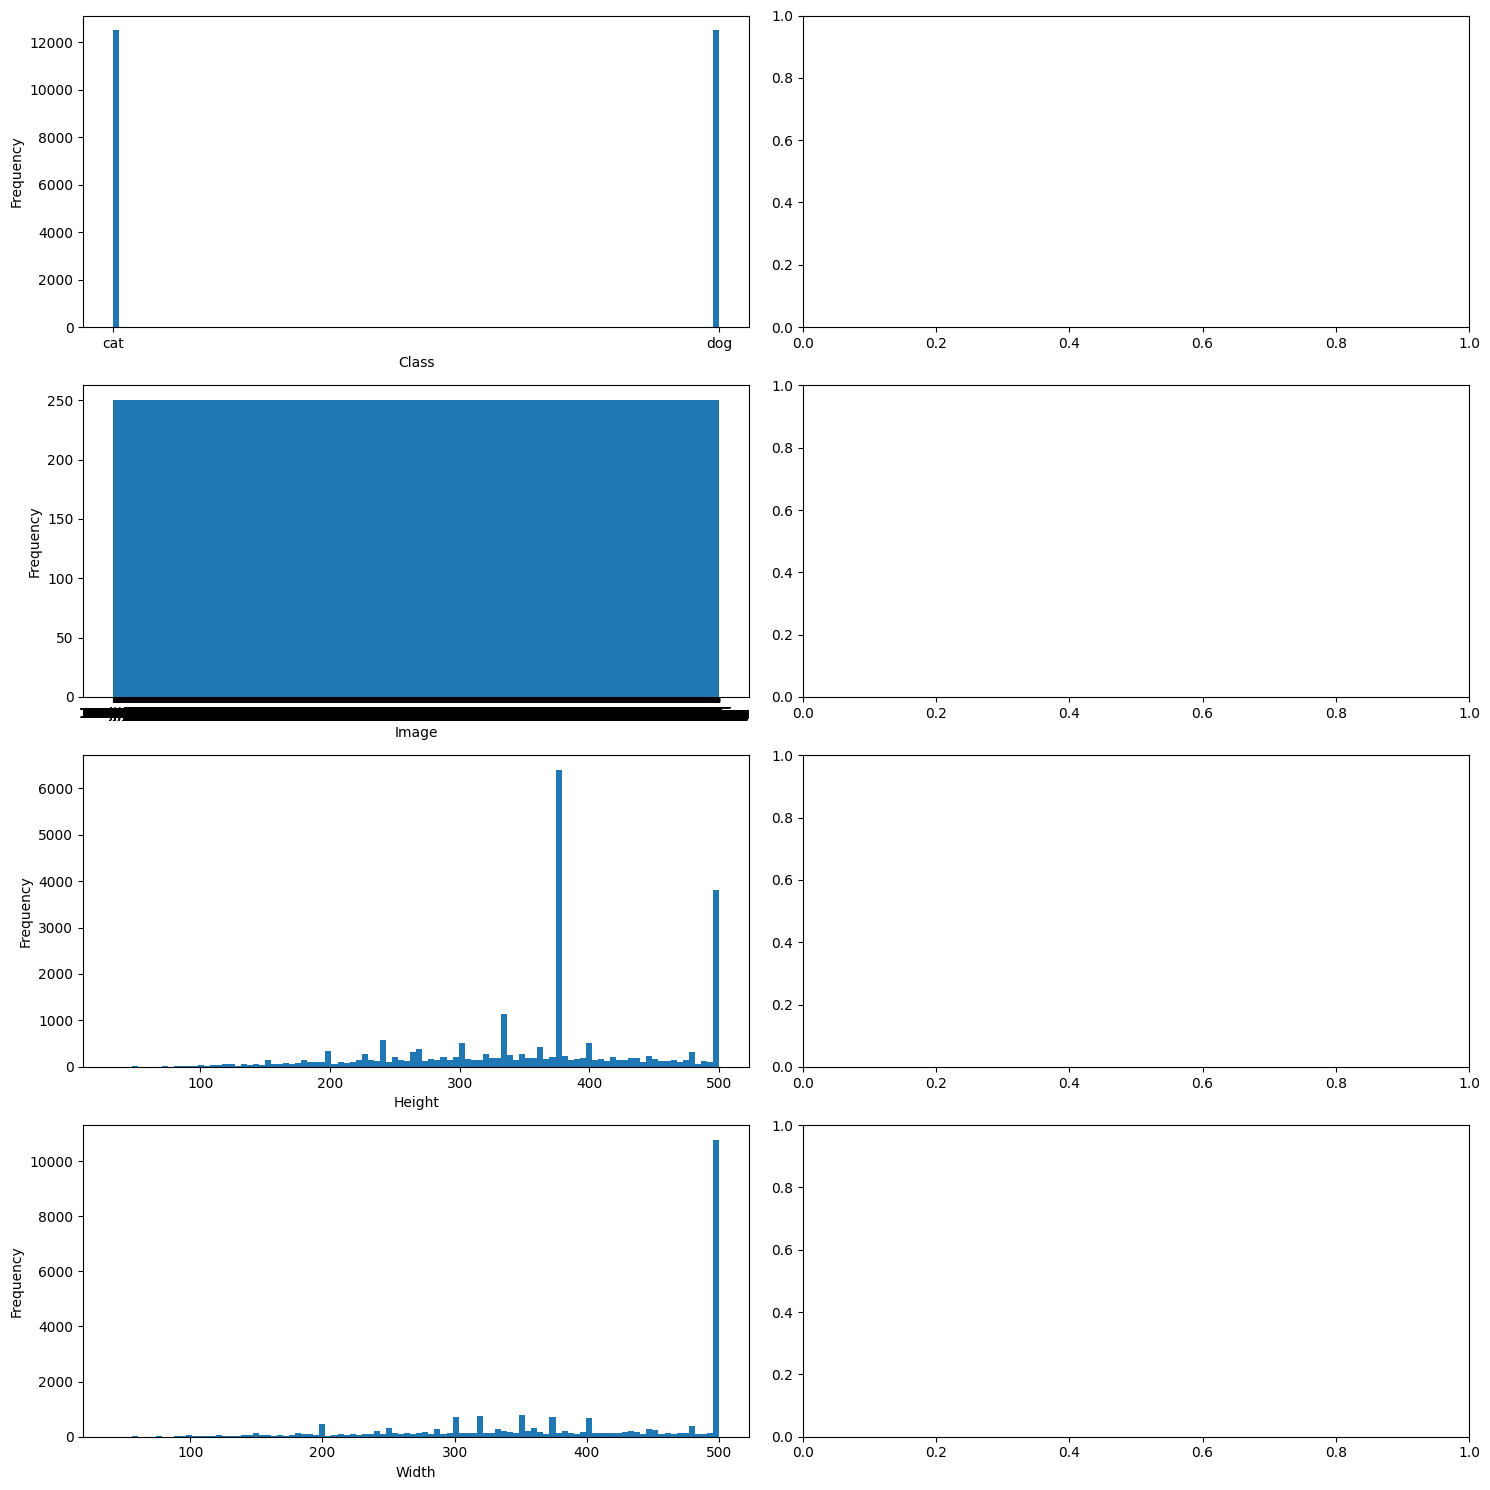

In [9]:
from Plotter import Plotter

metadata = metadata.drop(columns=['Is_Small'])

Plotter.plot_histogram(metadata)

- most images have high values of width and height. 
- Most images are ~380x~500 or ~500x~500 

#### **Network Creation**

- we will be creating a very small dataset of 200, 100, 50 images respectively initially. This will save us time and once the basic setup is done we will do the same iteration on medium and then the highest dataset. 

In [ ]:
from PL3DatasetCreator import PL3DatasetCreator
datasetCreator = PL3DatasetCreator(newdirName= "Nano")
datasetCreator.createDataset(0, 200, 75, 15)

In [11]:
class_map = {
    "cat": "data/Nano/train/cat",
    "dog": "data/Nano/train/dog"
}
imageEdaNano = EDAImage(class_map)
image_count_Nano = imageEdaNano.get_image_counts()
metadataNano = imageEdaNano.get_image_metadata()

display(image_count_Nano)
display(metadataNano.describe())

,Class,ImageCount
0,cat,200
1,dog,200


,Height,Width
count,400.000000,400.000000
mean,356.765000,403.050000
std,95.646932,112.058893
min,90.000000,80.000000
25%,300.000000,320.000000
50%,375.000000,453.000000
75%,400.250000,500.000000
max,500.000000,500.000000


In [12]:
from tensorflow.keras.utils import image_dataset_from_directory
import pathlib


data_folder = pathlib.Path("data/Nano")
train_dataset = image_dataset_from_directory(
    data_folder / "train",
    image_size=(180, 180),
    batch_size=32)
validation_dataset = image_dataset_from_directory(
    data_folder  / "validation",
    image_size=(180, 180),
    batch_size=32)
test_dataset = image_dataset_from_directory(
    data_folder  / "test",
    image_size=(180, 180),
    batch_size=32)

Found 400 files belonging to 2 classes.
Found 66 files belonging to 2 classes.
Found 40 files belonging to 2 classes.


Found 400 files belonging to 2 classes.
Found 66 files belonging to 2 classes.
Found 40 files belonging to 2 classes.
Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 180, 180, 3)]     0         
                                                                 
 rescaling (Rescaling)       (None, 180, 180, 3)       0         
                                                                 
 conv2d (Conv2D)             (None, 178, 178, 32)      896       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 89, 89, 32)       0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 87, 87, 64)        18496     
                                                                 
 max_pool

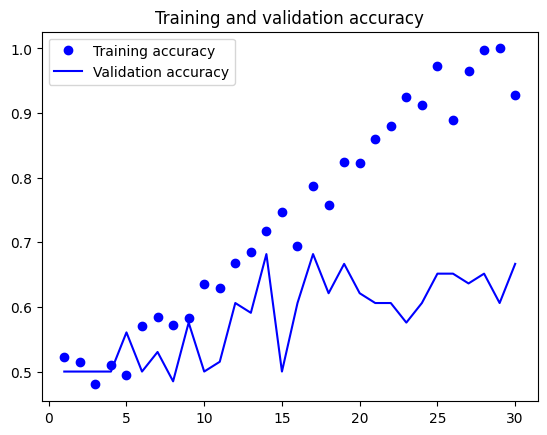

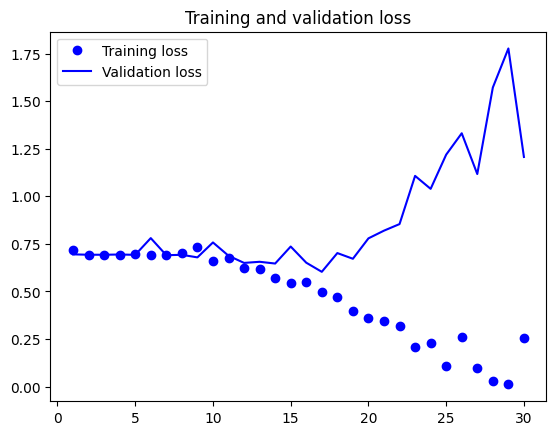

Model: "model_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 180, 180, 3)]     0         
                                                                 
 rescaling_1 (Rescaling)     (None, 180, 180, 3)       0         
                                                                 
 conv2d_5 (Conv2D)           (None, 178, 178, 32)      896       
                                                                 
 max_pooling2d_4 (MaxPooling  (None, 89, 89, 32)       0         
 2D)                                                             
                                                                 
 conv2d_6 (Conv2D)           (None, 87, 87, 64)        18496     
                                                                 
 max_pooling2d_5 (MaxPooling  (None, 43, 43, 64)       0         
 2D)                                                       

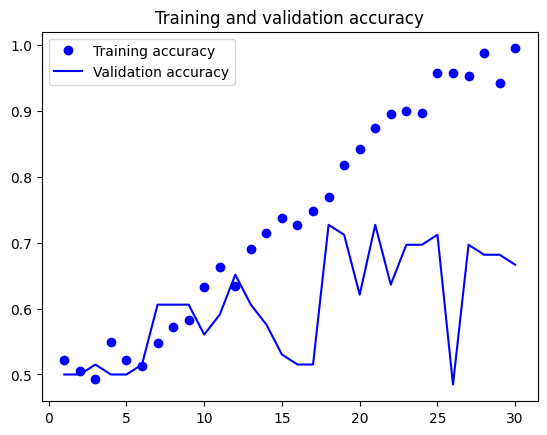

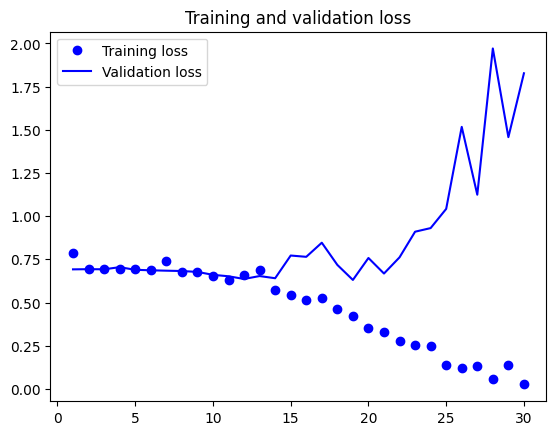

Model: "model_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_3 (InputLayer)        [(None, 180, 180, 3)]     0         
                                                                 
 rescaling_2 (Rescaling)     (None, 180, 180, 3)       0         
                                                                 
 conv2d_10 (Conv2D)          (None, 178, 178, 32)      896       
                                                                 
 max_pooling2d_8 (MaxPooling  (None, 89, 89, 32)       0         
 2D)                                                             
                                                                 
 conv2d_11 (Conv2D)          (None, 87, 87, 64)        18496     
                                                                 
 max_pooling2d_9 (MaxPooling  (None, 43, 43, 64)       0         
 2D)                                                       

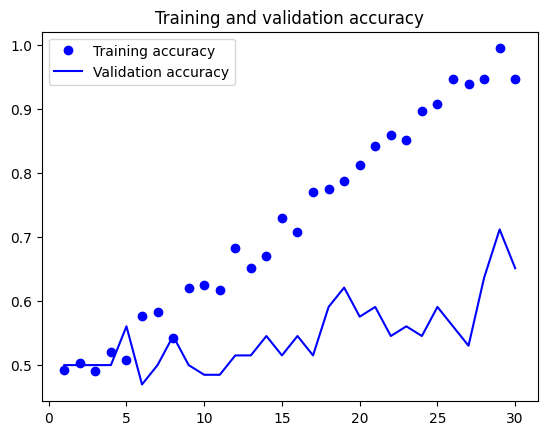

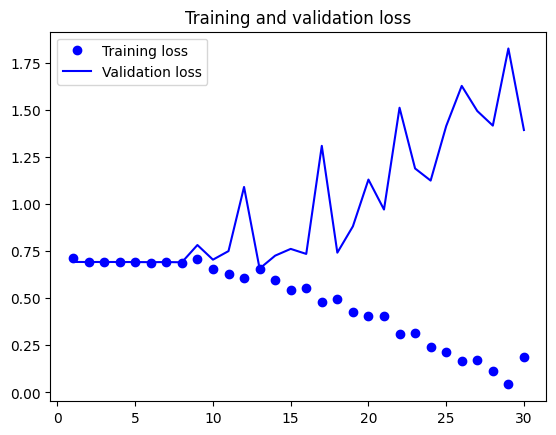

Model: "model_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_4 (InputLayer)        [(None, 180, 180, 3)]     0         
                                                                 
 rescaling_3 (Rescaling)     (None, 180, 180, 3)       0         
                                                                 
 conv2d_15 (Conv2D)          (None, 178, 178, 32)      896       
                                                                 
 max_pooling2d_12 (MaxPoolin  (None, 89, 89, 32)       0         
 g2D)                                                            
                                                                 
 conv2d_16 (Conv2D)          (None, 87, 87, 64)        18496     
                                                                 
 max_pooling2d_13 (MaxPoolin  (None, 43, 43, 64)       0         
 g2D)                                                      

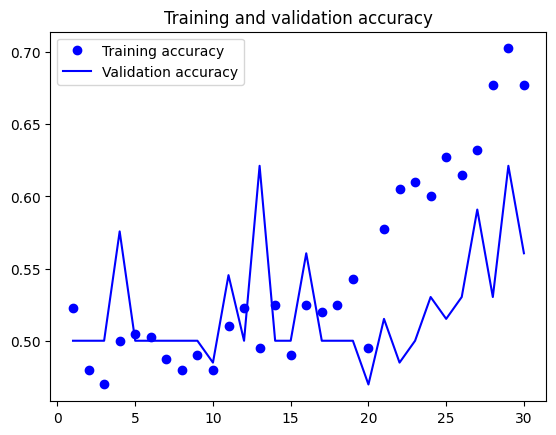

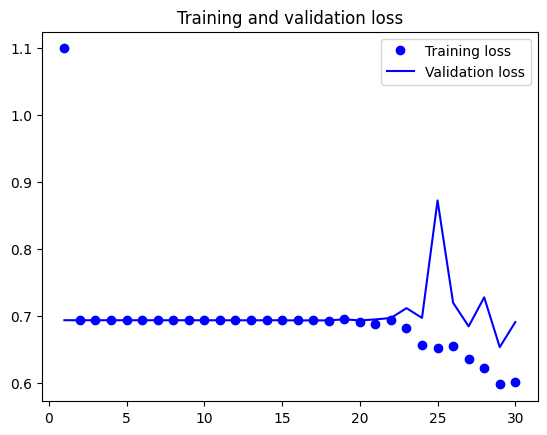

Model: "model_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_5 (InputLayer)        [(None, 180, 180, 3)]     0         
                                                                 
 rescaling_4 (Rescaling)     (None, 180, 180, 3)       0         
                                                                 
 conv2d_20 (Conv2D)          (None, 178, 178, 128)     3584      
                                                                 
 max_pooling2d_16 (MaxPoolin  (None, 89, 89, 128)      0         
 g2D)                                                            
                                                                 
 conv2d_21 (Conv2D)          (None, 87, 87, 32)        36896     
                                                                 
 max_pooling2d_17 (MaxPoolin  (None, 43, 43, 32)       0         
 g2D)                                                      

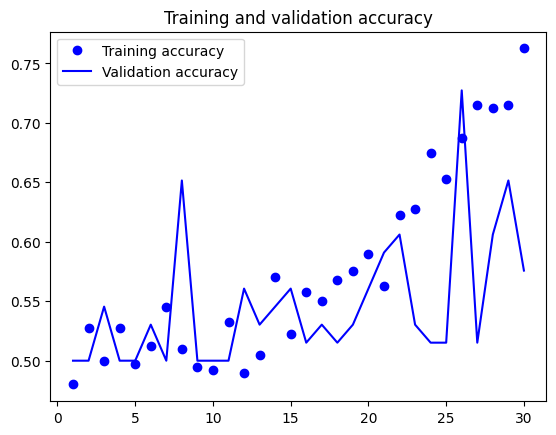

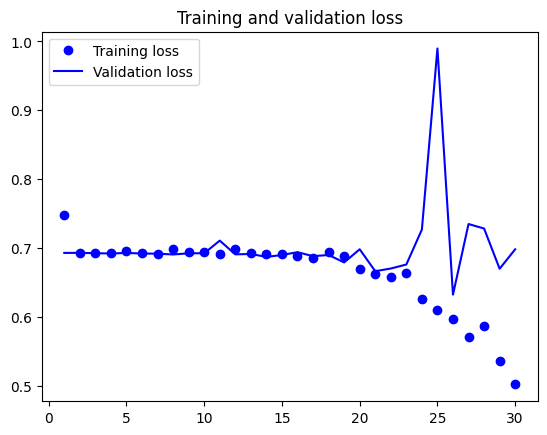

In [1]:
from tensorflow.keras.utils import image_dataset_from_directory
import pathlib
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
from tensorflow.keras.metrics import Precision
from tensorflow.keras.metrics import Recall

from NeuralNetworkEvaluator import NeuralNetworkEvaluator
from CustomNeuralNetwork import CustomNeuralNetwork
from CustomNeuralNetwork2 import CustomNeuralNetwork2
from CustomNeuralNetwork3 import CustomNeuralNetwork3
from CustomNeuralNetwork4 import CustomNeuralNetwork4
from CustomNeuralNetwork5 import CustomNeuralNetwork5

valuator = NeuralNetworkEvaluator("data/Nano")

customNN = CustomNeuralNetwork()
customNN.model.summary()
customModel = customNN.model
valuator.trainandvalidate(customModel, "Nano", "customNN")

customNN = CustomNeuralNetwork2()
customNN.model.summary()
customModel = customNN.model
valuator.trainandvalidate(customModel, "Nano","customNN2")

customNN = CustomNeuralNetwork3()
customNN.model.summary()
customModel = customNN.model
valuator.trainandvalidate(customModel, "Nano","customNN3")

customNN = CustomNeuralNetwork4()
customNN.model.summary()
customModel = customNN.model
valuator.trainandvalidate(customModel, "Nano","customNN4")

customNN = CustomNeuralNetwork5()
customNN.model.summary()
customModel = customNN.model
valuator.trainandvalidate(customModel, "Nano","customNN5")

- From all the 5 models we trained we can see that 2nd one was giving a better result at epoch 12.
- We can select that model as the custom model.

#### **Test Evaluation for CustomNeuralNetwork2**

Found 40 files belonging to 2 classes.
Model Evaluation Results:
--------------------------------------------------
2/2 [==============================] - 1s 76ms/step - loss: 0.6778 - accuracy: 0.7000 - auc: 0.7500 - precision_1: 0.6250 - recall_1: 1.0000

Test Accuracy: 0.7000
1/1 [==============================] - 0s 183ms/step


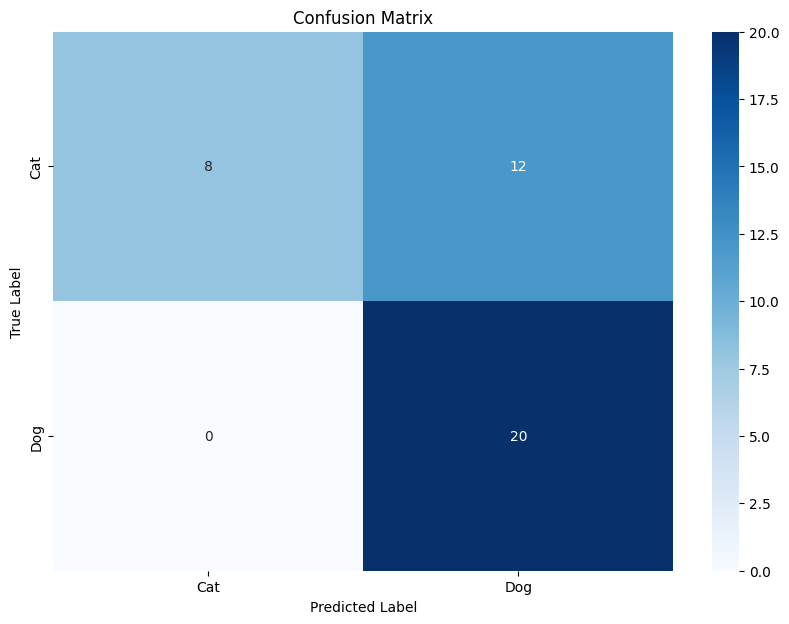

1/1 [==============================] - 0s 76ms/step

Classification Report:
              precision    recall  f1-score   support

         Cat       1.00      0.40      0.57        20
         Dog       0.62      1.00      0.77        20

    accuracy                           0.70        40
   macro avg       0.81      0.70      0.67        40
weighted avg       0.81      0.70      0.67        40

1/1 [==============================] - 0s 88ms/step


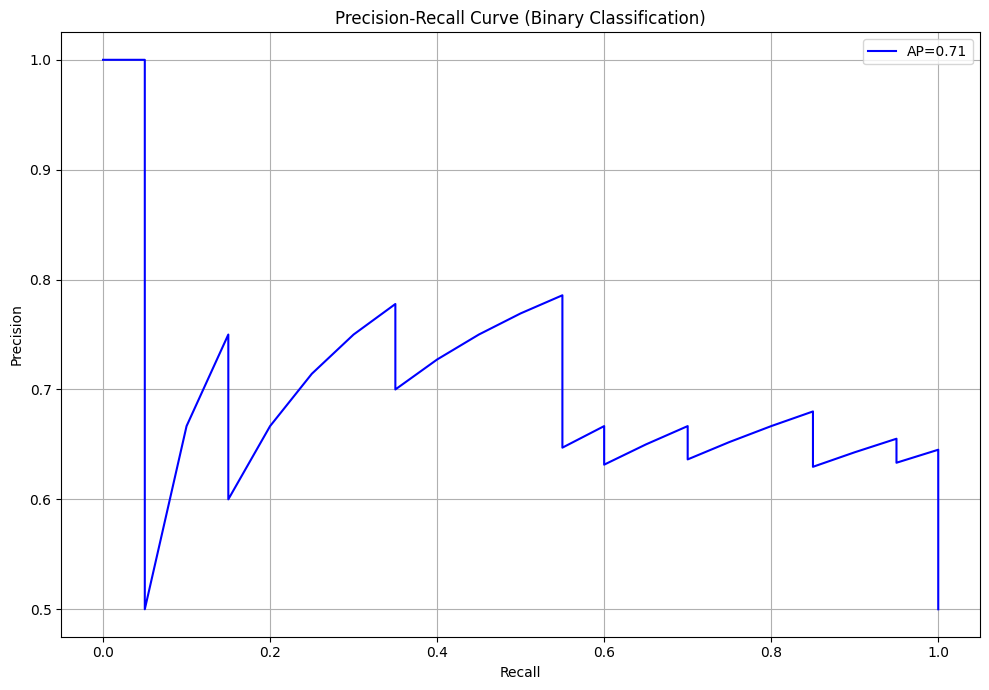

1/1 [==============================] - 0s 239ms/step
Actual : 0 Predicted: 1


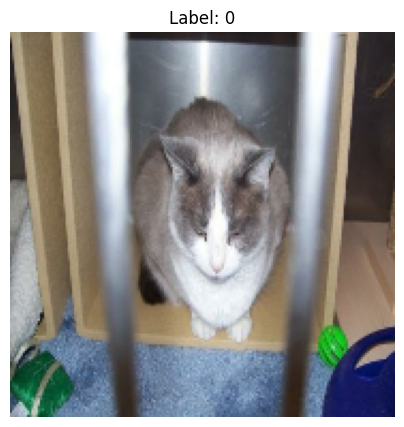

Actual : 0 Predicted: 1


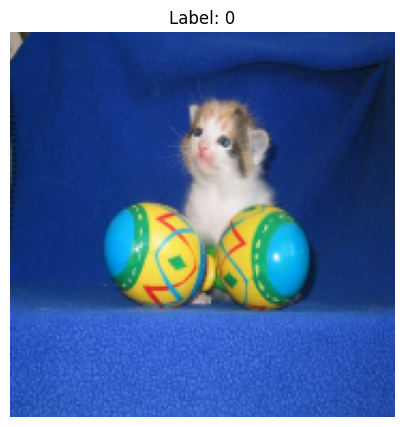

Actual : 0 Predicted: 1


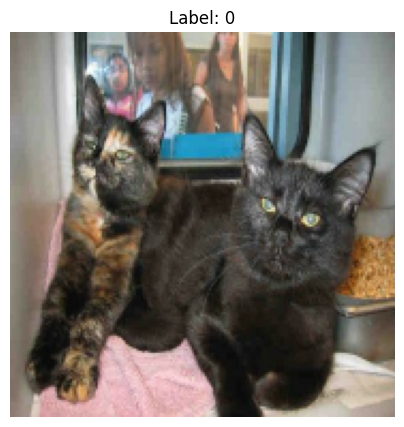

Actual : 0 Predicted: 1


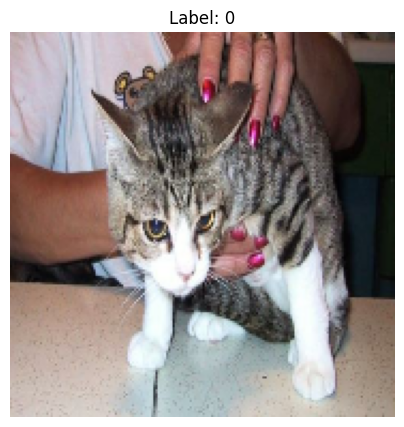

Actual : 0 Predicted: 1


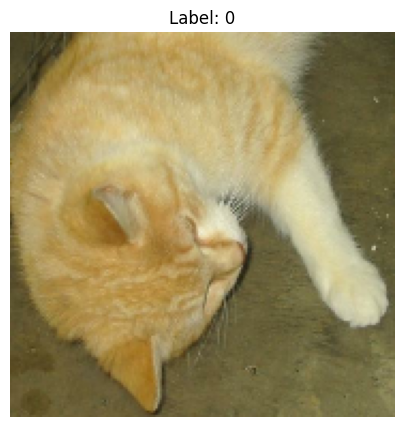

Actual : 0 Predicted: 1


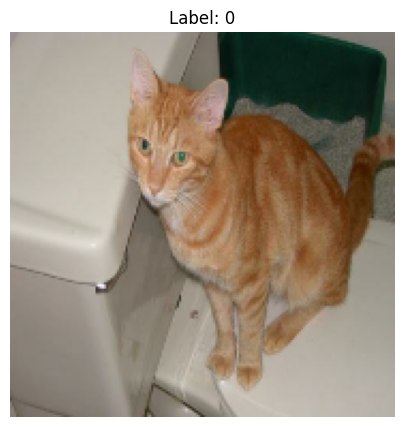

Actual : 0 Predicted: 1


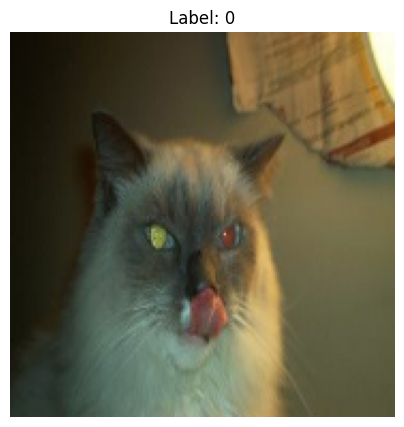

Actual : 0 Predicted: 1


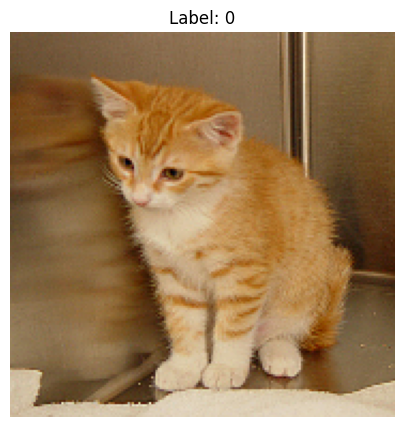

Actual : 0 Predicted: 1


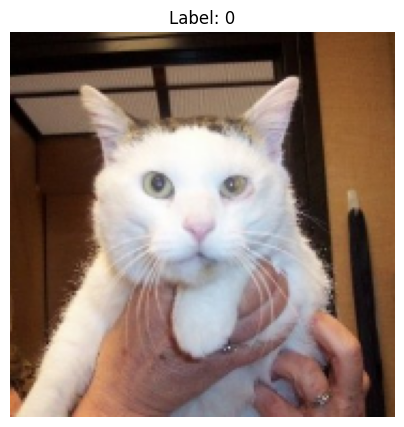

Actual : 0 Predicted: 1


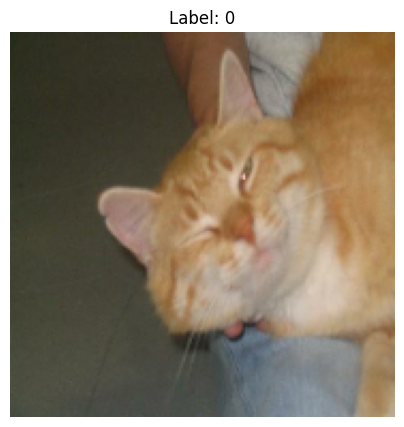

Actual : 0 Predicted: 1


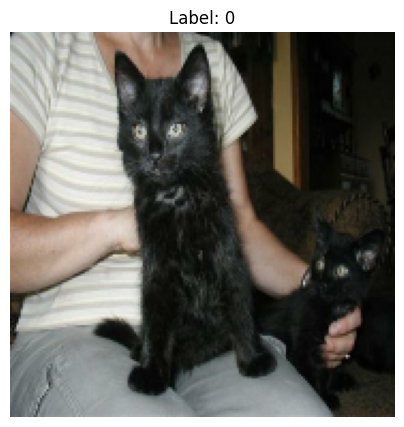

Actual : 0 Predicted: 1


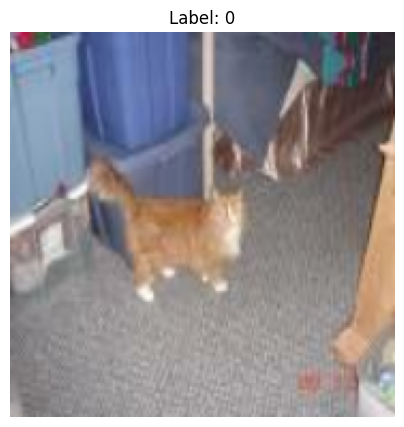

1/1 [==============================] - 0s 104ms/step


{'accuracy': 0.699999988079071,
 'confusion_matrix': array([[ 8, 12],
        [ 0, 20]], dtype=int64),
 'classification_metrics': {'Cat': {'precision': 1.0,
   'recall': 0.4,
   'f1-score': 0.5714285714285715,
   'support': 20.0},
  'Dog': {'precision': 0.625,
   'recall': 1.0,
   'f1-score': 0.7692307692307693,
   'support': 20.0},
  'accuracy': 0.7,
  'macro avg': {'precision': 0.8125,
   'recall': 0.7,
   'f1-score': 0.6703296703296704,
   'support': 40.0},
  'weighted avg': {'precision': 0.8125,
   'recall': 0.7,
   'f1-score': 0.6703296703296704,
   'support': 40.0}}}

In [1]:
from NeuralNetworkTestEvaluator import NeuralNetworkTestEvaluator
from tensorflow import keras


test_model_cnn2_nano = keras.models.load_model(
    "./models/Nano/customNN2/11-22-15-48/model.keras")
cnn2NanoTestEvaluator = NeuralNetworkTestEvaluator("data/Nano", test_model_cnn2_nano, 13)
cnn2NanoTestEvaluator.evaluate_model()


- After evaluations we find that cats are getting misclassified as dogs.
- All dogs were correctly identified on the test set with precision 1. 
- Accuracy is 70%.
- We can try the same in a bigger dataset now. 